<a href="https://colab.research.google.com/github/JayadharsiniMathiyalagan/Fundamentals-of-Machine-Learning/blob/main/FOML_EXP_8(a).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

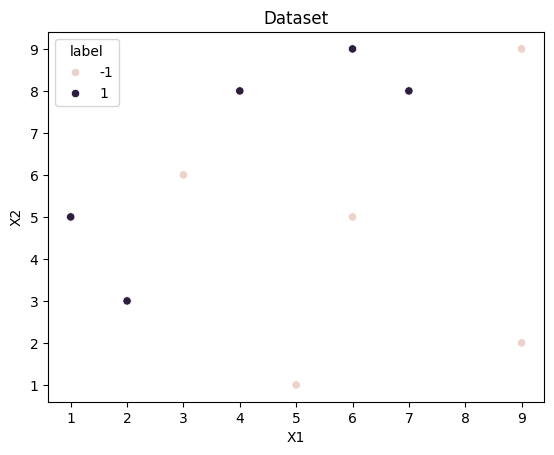

Model 1 → Error: 0.3000, Alpha: 0.4236
Model 2 → Error: 0.2143, Alpha: 0.6496
Model 3 → Error: 0.1970, Alpha: 0.7027

Final Accuracy: 0.9

Prediction for [1,5]: [1.]
Prediction for [9,9]: [1.]


In [9]:
# ==============================
# STEP 1: Import Libraries
# ==============================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# ==============================
# STEP 2: Create Dataset
# ==============================
df = pd.DataFrame({
    'X1': [1,2,3,4,5,6,6,7,9,9],
    'X2': [5,3,6,8,1,9,5,8,9,2],
    'label': [1,1,0,1,0,1,0,1,0,0]
})

# Convert labels (0 → -1 for AdaBoost math)
df['label'] = df['label'].replace(0, -1)

# Plot data
sns.scatterplot(x='X1', y='X2', hue='label', data=df)
plt.title("Dataset")
plt.show()

# ==============================
# STEP 3: Initialize Weights
# ==============================
n = df.shape[0]
weights = np.ones(n) / n

X = df[['X1','X2']].values
y = df['label'].values

# ==============================
# STEP 4: Train Weak Classifiers
# ==============================
n_estimators = 3
classifiers = []
alphas = []

for i in range(n_estimators):
    clf = DecisionTreeClassifier(max_depth=1)
    clf.fit(X, y, sample_weight=weights)

    pred = clf.predict(X)

    # Calculate error
    error = np.sum(weights * (pred != y)) / np.sum(weights)

    # Avoid division by zero
    error = max(error, 1e-10)

    # Calculate alpha
    alpha = 0.5 * np.log((1 - error) / error)

    # Update weights
    weights = weights * np.exp(-alpha * y * pred)
    weights = weights / np.sum(weights)

    classifiers.append(clf)
    alphas.append(alpha)

    print(f"Model {i+1} → Error: {error:.4f}, Alpha: {alpha:.4f}")

# ==============================
# STEP 5: Prediction Function
# ==============================
def adaboost_predict(X):
    final_pred = np.zeros(X.shape[0])

    for alpha, clf in zip(alphas, classifiers):
        final_pred += alpha * clf.predict(X)

    return np.sign(final_pred)

# ==============================
# STEP 6: Evaluate Model
# ==============================
y_pred = adaboost_predict(X)

accuracy = accuracy_score(y, y_pred)
print("\nFinal Accuracy:", accuracy)

# ==============================
# STEP 7: Test on New Data
# ==============================
query1 = np.array([[1,5]])
query2 = np.array([[9,9]])

print("\nPrediction for [1,5]:", adaboost_predict(query1))
print("Prediction for [9,9]:", adaboost_predict(query2))